# 01_data_prep.ipynb

> Data preparation for credit risk and churn domains
> Loads raw public datasets, cleans, encodes, and creates train/test splits

Directories ready.
[credit] loaded: 32,581 rows x 12 columns
[churn] loaded: 7,043 rows x 21 columns

[credit] dtypes and missing values
                              dtype  n_missing  pct_missing  n_unique
person_age                    int64          0         0.00        58
person_income                 int64          0         0.00      4295
person_home_ownership           str          0         0.00         4
person_emp_length           float64        895         2.75        36
loan_intent                     str          0         0.00         6
loan_grade                      str          0         0.00         7
loan_amnt                     int64          0         0.00       753
loan_int_rate               float64       3116         9.56       348
loan_status                   int64          0         0.00         2
loan_percent_income         float64          0         0.00        77
cb_person_default_on_file       str          0         0.00         2
cb_person_cred_hist_len

,Domain,Role,N total,N train,N test,N features,Positive rate
0,credit,Primary,32409,22686,9723,22,0.2187
1,churn,Control,7021,4914,2107,30,0.2645


Saved: fig01_class_balance.png / fig01_class_balance.pdf


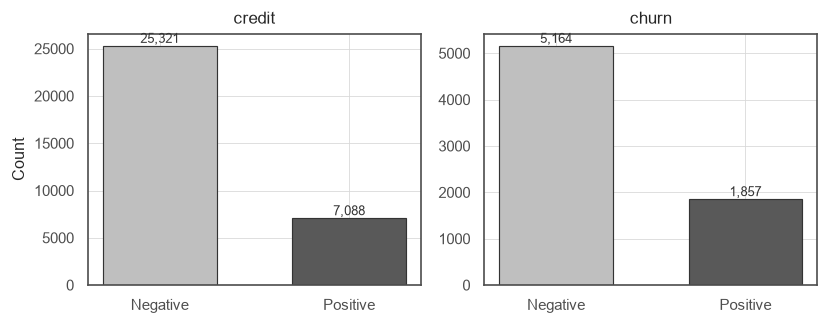

Saved: fig02_credit_feature_distributions.png / fig02_credit_feature_distributions.pdf


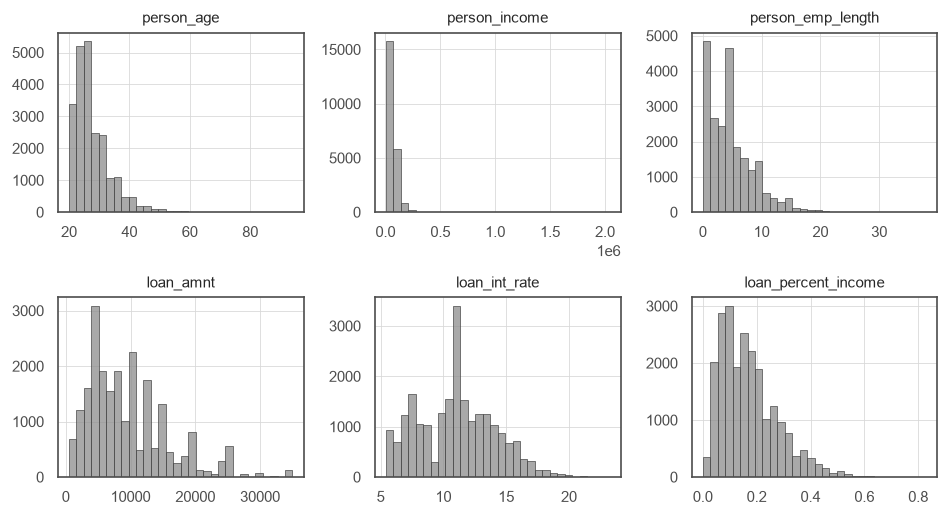

Processed files in data/:
  churn_X_test.parquet                         50.6 KB
  churn_X_train.parquet                        86.6 KB
  churn_y_test.parquet                          1.5 KB
  churn_y_train.parquet                         1.9 KB
  credit_X_test.parquet                       106.0 KB
  credit_X_train.parquet                      227.4 KB
  credit_y_test.parquet                         2.7 KB
  credit_y_train.parquet                        4.6 KB

Outputs in results/:
  results\figures\.gitkeep
  results\figures\fig01_class_balance.pdf
  results\figures\fig01_class_balance.png
  results\figures\fig02_credit_feature_distributions.pdf
  results\figures\fig02_credit_feature_distributions.png
  results\tables\.gitkeep
  results\tables\tab01_dataset_summary.csv

Next step: 02_model_training.ipynb


In [1]:
# ============================================================================
# 01_data_prep.ipynb
# Data preparation for credit risk and churn domains
# Loads raw public datasets, cleans, encodes, and creates train/test splits
# ============================================================================


# [Cell 1] Imports and global configuration
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Directory layout
ROOT = Path("..")
DATA_DIR = ROOT / "data"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"

for d in [DATA_DIR, FIG_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Directories ready.")


# [Cell 2] Plotting style: grayscale, publication settings
# Grayscale palette for all figures in this study
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette(sns.color_palette("gray", n_colors=8))

plt.rcParams.update({
    "figure.dpi": 120,          # on-screen preview
    "savefig.dpi": 600,         # export resolution
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.5,
    "axes.edgecolor": "0.3",
    "axes.labelcolor": "0.15",
    "text.color": "0.15",
    "xtick.color": "0.3",
    "ytick.color": "0.3",
    "image.cmap": "gray",
    "savefig.bbox": "tight",
    "savefig.transparent": False,
})


def save_fig(fig, name):
    """Save a figure as both PNG and PDF at 600 dpi. No caption is added."""
    for ext in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")
    print(f"Saved: {name}.png / {name}.pdf")


def save_table(df, name, index=False):
    """Save a table as CSV under results/tables."""
    df.to_csv(TAB_DIR / f"{name}.csv", index=index, encoding="utf-8-sig")
    print(f"Saved: {name}.csv")


# [Cell 3] Dataset specifications
# Two domains:
#   credit -> high-impact domain (primary analysis)
#   churn  -> control domain (Block A' only)
DATASETS = {
    "credit": {
        "file": "credit_risk_dataset.csv",
        "target": "loan_status",          # 1 = default, 0 = non-default
        "positive_meaning": "default",
        "drop_cols": [],
    },
    "churn": {
        "file": "telco_churn.csv",
        "target": "Churn",                # Yes / No
        "positive_meaning": "churn",
        "drop_cols": ["customerID"],
    },
}

TEST_SIZE = 0.30


# [Cell 4] Load raw data
def load_raw(domain):
    """Read a raw CSV for the given domain."""
    spec = DATASETS[domain]
    path = DATA_DIR / spec["file"]
    if not path.exists():
        raise FileNotFoundError(
            f"Raw file not found: {path}\n"
            f"Place the public dataset in the data/ folder first."
        )
    df = pd.read_csv(path)
    print(f"[{domain}] loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
    return df


raw = {d: load_raw(d) for d in DATASETS}


# [Cell 5] Inspect raw structure
for domain, df in raw.items():
    print(f"\n{'=' * 60}\n[{domain}] dtypes and missing values\n{'=' * 60}")
    info = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(),
    })
    print(info.to_string())


# [Cell 6] Cleaning utilities
def clean_target(df, domain):
    """Convert the target column to a binary integer (1 = adverse outcome)."""
    spec = DATASETS[domain]
    col = spec["target"]
    s = df[col]
    df_original_values = df[col].unique()[:20]

    # Not `s.dtype == object`: pandas 3.x reports string columns as `str`,
    # which would skip the mapping and silently drop every row.
    if not pd.api.types.is_numeric_dtype(s):
        mapping = {"yes": 1, "no": 0, "true": 1, "false": 0, "1": 1, "0": 0}
        s = s.astype(str).str.strip().str.lower().map(mapping)

    df = df.copy()
    df[col] = pd.to_numeric(s, errors="coerce").astype("Int64")

    n_before = len(df)
    df = df.dropna(subset=[col])
    if len(df) == 0:
        observed = sorted({str(v) for v in df_original_values})[:6]
        raise ValueError(
            f"[{domain}] every row was dropped when cleaning '{col}'. "
            f"Observed target values: {observed}"
        )
    if n_before - len(df):
        print(f"  [{domain}] dropped {n_before - len(df):,} rows with unmappable target")

    df[col] = df[col].astype(int)
    return df


def coerce_numeric(df, cols):
    """Force selected columns to numeric, turning malformed entries into NaN."""
    df = df.copy()
    for c in cols:
        df[c] = pd.to_numeric(df[c].replace(" ", np.nan), errors="coerce")
    return df


def impute(df, target_col):
    """Median imputation for numeric columns, mode for categorical columns."""
    df = df.copy()
    feats = [c for c in df.columns if c != target_col]
    for c in feats:
        if df[c].isna().sum() == 0:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            df[c] = df[c].fillna(df[c].median())
        else:
            df[c] = df[c].fillna(df[c].mode().iloc[0])
    return df


# [Cell 7] Domain-specific cleaning
def prepare_credit(df):
    """Clean the credit risk dataset."""
    df = df.copy()
    df = clean_target(df, "credit")

    # Duplicates would be sampled as separate cases in 03, so the same applicant
    # could enter the analysis twice. Removed before imputation, since imputing
    # first would turn distinct rows into artificial duplicates.
    n_before = len(df)
    df = df.drop_duplicates()
    print(f"  [credit] duplicates removed: {n_before - len(df):,}")

    # Remove implausible outliers commonly present in this public dataset
    if "person_age" in df.columns:
        df = df[df["person_age"] <= 100]
    if "person_emp_length" in df.columns:
        df = df[df["person_emp_length"].isna() | (df["person_emp_length"] <= 60)]
    df = impute(df, DATASETS["credit"]["target"])
    return df.reset_index(drop=True)


def prepare_churn(df):
    """Clean the Telco churn dataset."""
    df = df.copy()
    df = df.drop(columns=[c for c in DATASETS["churn"]["drop_cols"] if c in df.columns])

    # customerID is dropped above, so any remaining duplicate is a customer
    # whose every attribute coincides with another's.
    n_before = len(df)
    df = df.drop_duplicates()
    print(f"  [churn] duplicates removed: {n_before - len(df):,}")

    # TotalCharges is stored as text with blank entries in the public release
    if "TotalCharges" in df.columns:
        df = coerce_numeric(df, ["TotalCharges"])
    df = clean_target(df, "churn")
    df = impute(df, DATASETS["churn"]["target"])
    return df.reset_index(drop=True)


PREPARERS = {"credit": prepare_credit, "churn": prepare_churn}
clean = {d: PREPARERS[d](raw[d]) for d in DATASETS}

for d, df in clean.items():
    tgt = DATASETS[d]["target"]
    rate = df[tgt].mean()
    print(f"[{d}] cleaned: {df.shape[0]:,} rows, positive rate = {rate:.3f}")


# [Cell 8] Feature encoding
# One-hot encoding keeps feature names human-readable, which matters because
# claim extraction later has to match feature names mentioned in narratives.
def encode_features(df, target_col):
    """One-hot encode categorical columns; leave numeric columns unchanged."""
    y = df[target_col]
    X = df.drop(columns=[target_col])

    # "string"/"str" are included because pandas 3.x no longer reports text
    # columns as object dtype.
    cat_cols = X.select_dtypes(
        include=["object", "string", "str", "category"]
    ).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    X_enc = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)
    # Normalise column names for downstream matching
    X_enc.columns = (
        X_enc.columns.str.replace(" ", "_", regex=False)
                     .str.replace("-", "_", regex=False)
                     .str.replace("(", "", regex=False)
                     .str.replace(")", "", regex=False)
    )
    print(f"  numeric: {len(num_cols)}, categorical: {len(cat_cols)} "
          f"-> encoded: {X_enc.shape[1]} features")
    return X_enc, y, num_cols, cat_cols


encoded = {}
for d, df in clean.items():
    print(f"[{d}] encoding")
    X, y, num_cols, cat_cols = encode_features(df, DATASETS[d]["target"])
    encoded[d] = {"X": X, "y": y, "num_cols": num_cols, "cat_cols": cat_cols}


# [Cell 9] Train/test split
# A single fixed split is shared by every model, XAI method, LLM and prompt
# so that variability observed later cannot be attributed to data partitioning.
splits = {}
for d in DATASETS:
    X, y = encoded[d]["X"], encoded[d]["y"]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
    )
    splits[d] = {
        "X_train": X_tr.reset_index(drop=True),
        "X_test": X_te.reset_index(drop=True),
        "y_train": y_tr.reset_index(drop=True),
        "y_test": y_te.reset_index(drop=True),
    }
    print(f"[{d}] train = {len(X_tr):,} / test = {len(X_te):,} "
          f"| positive rate train {y_tr.mean():.3f}, test {y_te.mean():.3f}")


# [Cell 10] Persist processed data
for d, sp in splits.items():
    for key, obj in sp.items():
        out = DATA_DIR / f"{d}_{key}.parquet"
        frame = obj.to_frame() if isinstance(obj, pd.Series) else obj
        frame.to_parquet(out, index=False)
        print(f"Saved: {out.name}")

# Feature name registry, used later by the claim extraction parser
feature_registry = {
    d: {
        "features": encoded[d]["X"].columns.tolist(),
        "numeric_original": encoded[d]["num_cols"],
        "categorical_original": encoded[d]["cat_cols"],
        "target": DATASETS[d]["target"],
        "positive_meaning": DATASETS[d]["positive_meaning"],
    }
    for d in DATASETS
}

with open(DATA_DIR / "feature_registry.json", "w", encoding="utf-8") as f:
    json.dump(feature_registry, f, ensure_ascii=False, indent=2)
print("Saved: feature_registry.json")


# [Cell 11] Summary table for the paper
rows = []
for d in DATASETS:
    sp = splits[d]
    rows.append({
        "Domain": d,
        "Role": "Primary" if d == "credit" else "Control",
        "N total": len(sp["X_train"]) + len(sp["X_test"]),
        "N train": len(sp["X_train"]),
        "N test": len(sp["X_test"]),
        "N features": sp["X_train"].shape[1],
        "Positive rate": round(float(pd.concat([sp["y_train"], sp["y_test"]]).mean()), 4),
    })

summary = pd.DataFrame(rows)
save_table(summary, "tab01_dataset_summary")
display(summary)


# [Cell 12] Figure: class balance by domain
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8))

for ax, d in zip(axes, DATASETS):
    y_all = pd.concat([splits[d]["y_train"], splits[d]["y_test"]])
    counts = y_all.value_counts().sort_index()
    ax.bar(
        ["Negative", "Positive"],
        counts.values,
        color=["0.75", "0.35"],
        edgecolor="0.2",
        linewidth=0.7,
        width=0.6,
    )
    ax.set_title(d, fontsize=10, color="0.15")
    ax.set_ylabel("Count" if d == "credit" else "")
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8, color="0.2")

plt.tight_layout()
save_fig(fig, "fig01_class_balance")
plt.show()


# [Cell 13] Figure: numeric feature distributions (primary domain)
num_feats = [
    c for c in encoded["credit"]["num_cols"]
    if c in splits["credit"]["X_train"].columns
][:6]

fig, axes = plt.subplots(2, 3, figsize=(8.0, 4.4))
for ax, col in zip(axes.ravel(), num_feats):
    sns.histplot(
        splits["credit"]["X_train"][col],
        bins=30, ax=ax, color="0.55",
        edgecolor="0.25", linewidth=0.4,
    )
    ax.set_title(col, fontsize=9, color="0.15")
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes.ravel()[len(num_feats):]:
    ax.axis("off")

plt.tight_layout()
save_fig(fig, "fig02_credit_feature_distributions")
plt.show()


# [Cell 14] Verification
print("Processed files in data/:")
for p in sorted(DATA_DIR.glob("*.parquet")):
    print(f"  {p.name:<40} {p.stat().st_size / 1024:>8.1f} KB")

print("\nOutputs in results/:")
for p in sorted(FIG_DIR.glob("*")) + sorted(TAB_DIR.glob("*")):
    print(f"  {p.relative_to(ROOT)}")

print("\nNext step: 02_model_training.ipynb")